In [1]:
# install the kagglehub package
!pip install kagglehub -q

import kagglehub

#Download dataset
path = kagglehub.dataset_download("uciml/electric-power-consumption-data-set")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\kdpco\.cache\kagglehub\datasets\uciml\electric-power-consumption-data-set\versions\1


In [2]:
import pandas as pd
import os

In [3]:
files = os.listdir(path)
print("Available files:", files)

Available files: ['household_power_consumption.txt']


In [4]:
csv_files = [f for f in files if f.endswith('.csv') or f.endswith('.txt')]
file_path = os.path.join(path, csv_files[0])
csv_files[0].endswith('.txt')
df = pd.read_csv(file_path, sep=';',parse_dates={'dt':['Date','Time']},index_col='dt')

C:\Users\kdpco\AppData\Local\Temp\ipykernel_21492\685336287.py:4: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, sep=';',parse_dates={'dt':['Date','Time']},index_col='dt')
C:\Users\kdpco\AppData\Local\Temp\ipykernel_21492\685336287.py:4: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(file_path, sep=';',parse_dates={'dt':['Date','Time']},index_col='dt')


In [5]:
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
dt,,,,,,,
2006-12-16 17:24:00,4.216,0.418,234.840,18.400,0.000,1.000,17.0
2006-12-16 17:25:00,5.360,0.436,233.630,23.000,0.000,1.000,16.0
2006-12-16 17:26:00,5.374,0.498,233.290,23.000,0.000,2.000,17.0
2006-12-16 17:27:00,5.388,0.502,233.740,23.000,0.000,1.000,17.0
2006-12-16 17:28:00,3.666,0.528,235.680,15.800,0.000,1.000,17.0


In [6]:
df.isnull().sum()

Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [7]:
df.shape

(2075259, 7)

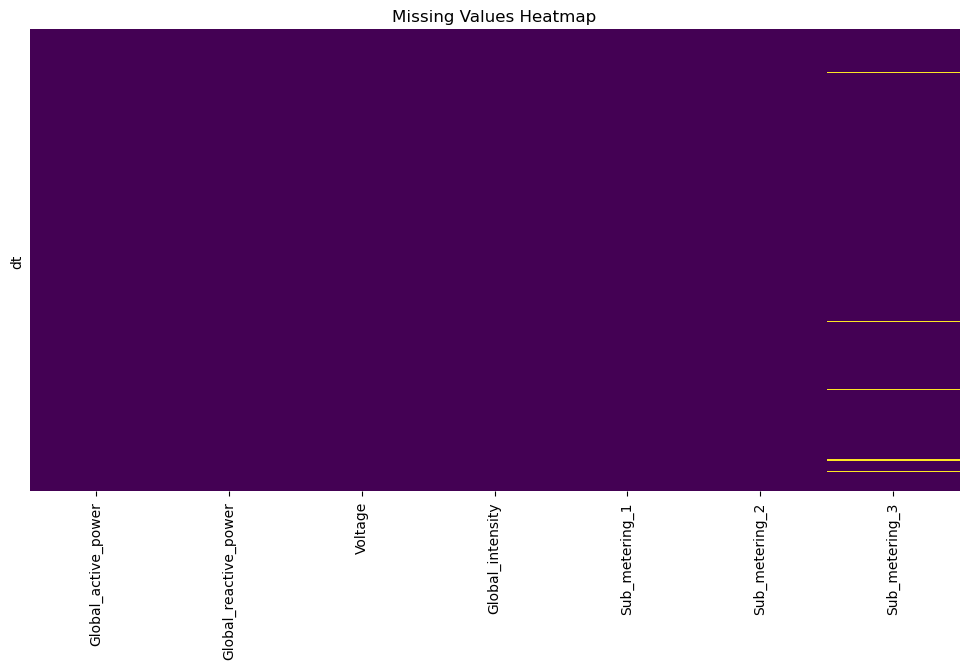

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [9]:
df['Sub_metering_3'] = df['Sub_metering_3'].ffill()
df.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [10]:
df.dtypes

Global_active_power       object
Global_reactive_power     object
Voltage                   object
Global_intensity          object
Sub_metering_1            object
Sub_metering_2            object
Sub_metering_3           float64
dtype: object

In [11]:
for col in ['Global_active_power', 'Global_reactive_power', 'Voltage',
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']:
    print(f"{col} unique non-numeric values:")
    # Convert to string first, drop NaNs to avoid float errors
    non_numeric = df[col].dropna().astype(str)
    # Remove one dot (for decimal), check if rest is digit
    mask = ~non_numeric.str.replace('.', '', 1).str.isnumeric()
    print(non_numeric[mask].unique())
    print()

Global_active_power unique non-numeric values:
['?']

Global_reactive_power unique non-numeric values:
['?']

Voltage unique non-numeric values:
['?']

Global_intensity unique non-numeric values:
['?']

Sub_metering_1 unique non-numeric values:
['?']

Sub_metering_2 unique non-numeric values:
['?']



In [12]:
import numpy as np

for col in ['Global_active_power', 'Global_reactive_power', 'Voltage',
            'Global_intensity', 'Sub_metering_1', 'Sub_metering_2']:
    df[col] = df[col].str.strip()  # remove leading/trailing spaces
    df[col] = df[col].replace(['?', '', 'NaN'], np.nan)  # treat weird values as missing

In [13]:
df[[
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2'
]] = df[[
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2'
]].astype(float)


In [14]:
# Convert relevant columns to numeric 
cols_to_convert = ['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3','Global_reactive_power','Voltage','Global_intensity']
df[cols_to_convert] = df[cols_to_convert].apply(pd.to_numeric, errors='coerce')
df.isna().sum()

Global_active_power      69622
Global_reactive_power    69622
Voltage                  69622
Global_intensity         69622
Sub_metering_1           69622
Sub_metering_2           69622
Sub_metering_3               0
dtype: int64

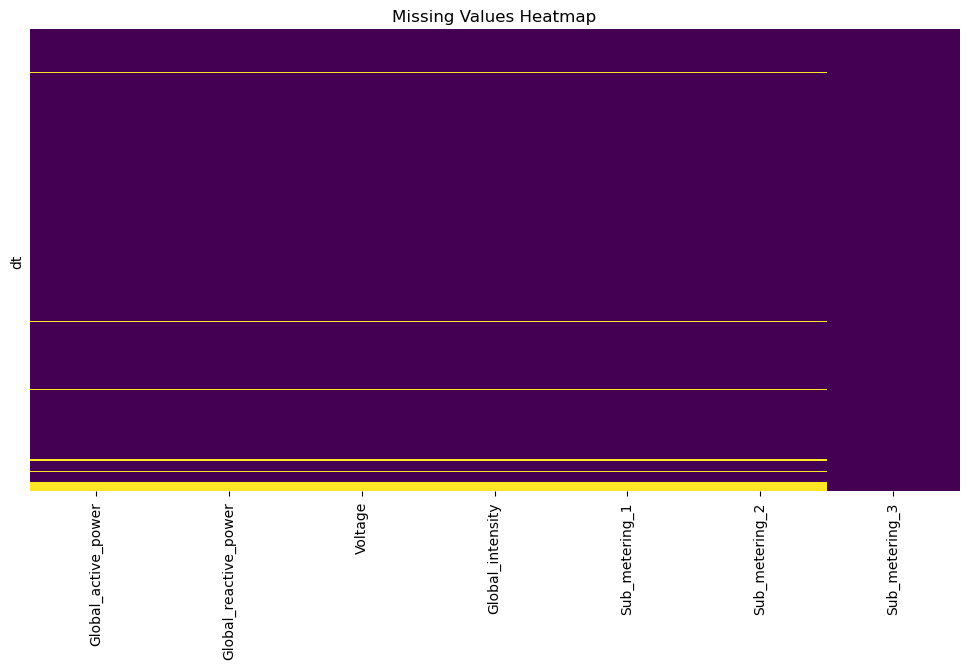

In [15]:
#plotting missing vlaues
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
sns.heatmap(df.isna(), cmap='viridis', cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

In [16]:
# Drop rows with any NaN values in key numeric columns
columns_to_check = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

df = df.dropna(subset=columns_to_check)

In [17]:
df.isna().sum()

Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64

In [18]:
df.shape

(2005637, 7)

In [19]:
df.dtypes

Global_active_power      float64
Global_reactive_power    float64
Voltage                  float64
Global_intensity         float64
Sub_metering_1           float64
Sub_metering_2           float64
Sub_metering_3           float64
dtype: object

In [20]:
# Calculate unmeasured energy in watt-hours per minute
df['Other_equipments_energy'] = (
    (df['Global_active_power'] * 1000 / 60) -
    (df['Sub_metering_1'] + df['Sub_metering_2'] + df['Sub_metering_3'])
)


In [21]:
# Move 'global_active_power' to the end
target = 'Global_active_power'

cols = [col for col in df.columns if col != target]

df = df[cols + [target]]
df.head()

,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_equipments_energy,Global_active_power
dt,,,,,,,,
2006-12-16 17:24:00,0.418,234.84,18.4,0.0,1.0,17.0,52.266667,4.216
2006-12-16 17:25:00,0.436,233.63,23.0,0.0,1.0,16.0,72.333333,5.360
2006-12-16 17:26:00,0.498,233.29,23.0,0.0,2.0,17.0,70.566667,5.374
2006-12-16 17:27:00,0.502,233.74,23.0,0.0,1.0,17.0,71.800000,5.388
2006-12-16 17:28:00,0.528,235.68,15.8,0.0,1.0,17.0,43.100000,3.666


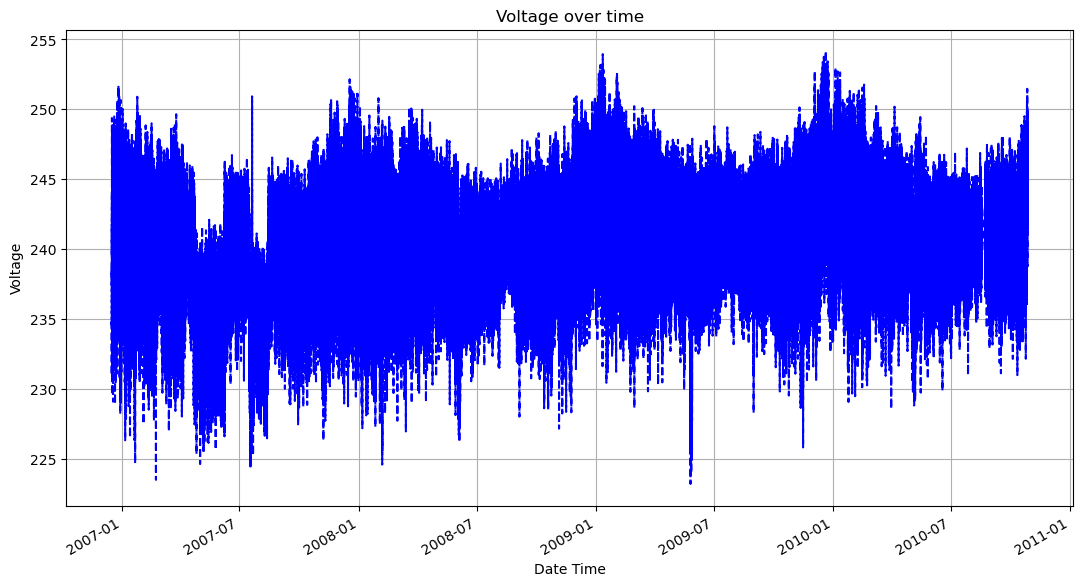

In [22]:
df['Voltage'].plot(figsize=(13, 7), linestyle='dashed', color='blue',
                             title='Voltage over time', grid=True)
plt.xlabel('Date Time')
plt.ylabel('Voltage')
plt.show()

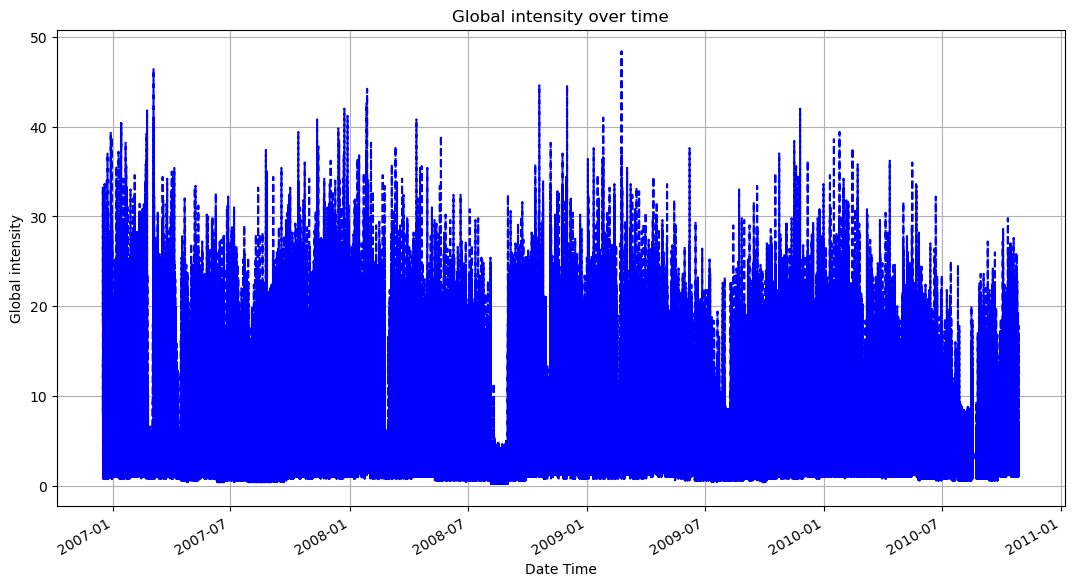

In [23]:
df['Global_intensity'].plot(figsize=(13, 7), linestyle='dashed', color='blue',
                             title='Global intensity over time', grid=True)
plt.xlabel('Date Time')
plt.ylabel('Global intensity')
plt.show()

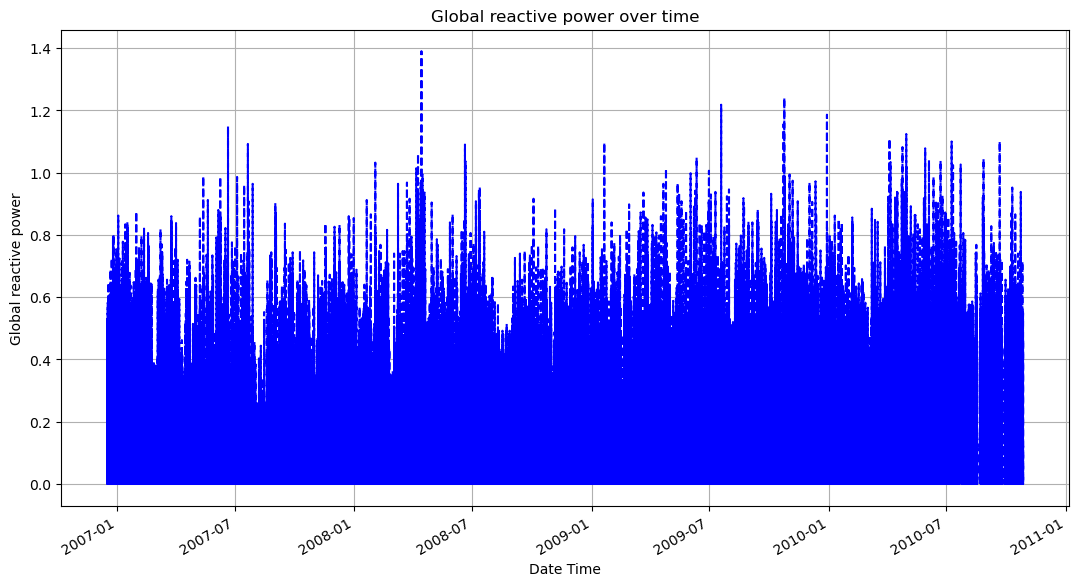

In [24]:
df['Global_reactive_power'].plot(figsize=(13, 7), linestyle='dashed', color='blue',
                             title='Global reactive power over time', grid=True)
plt.xlabel('Date Time')
plt.ylabel('Global reactive power')
plt.show()

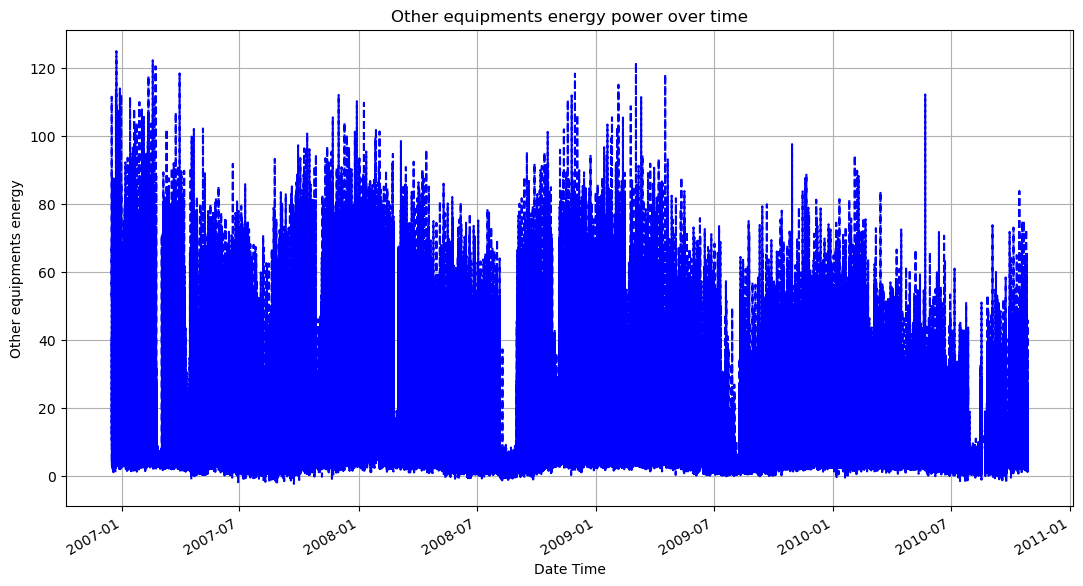

In [25]:
df['Other_equipments_energy'].plot(figsize=(13, 7), linestyle='dashed', color='blue',
                             title='Other equipments energy power over time', grid=True)
plt.xlabel('Date Time')
plt.ylabel('Other equipments energy')
plt.show()

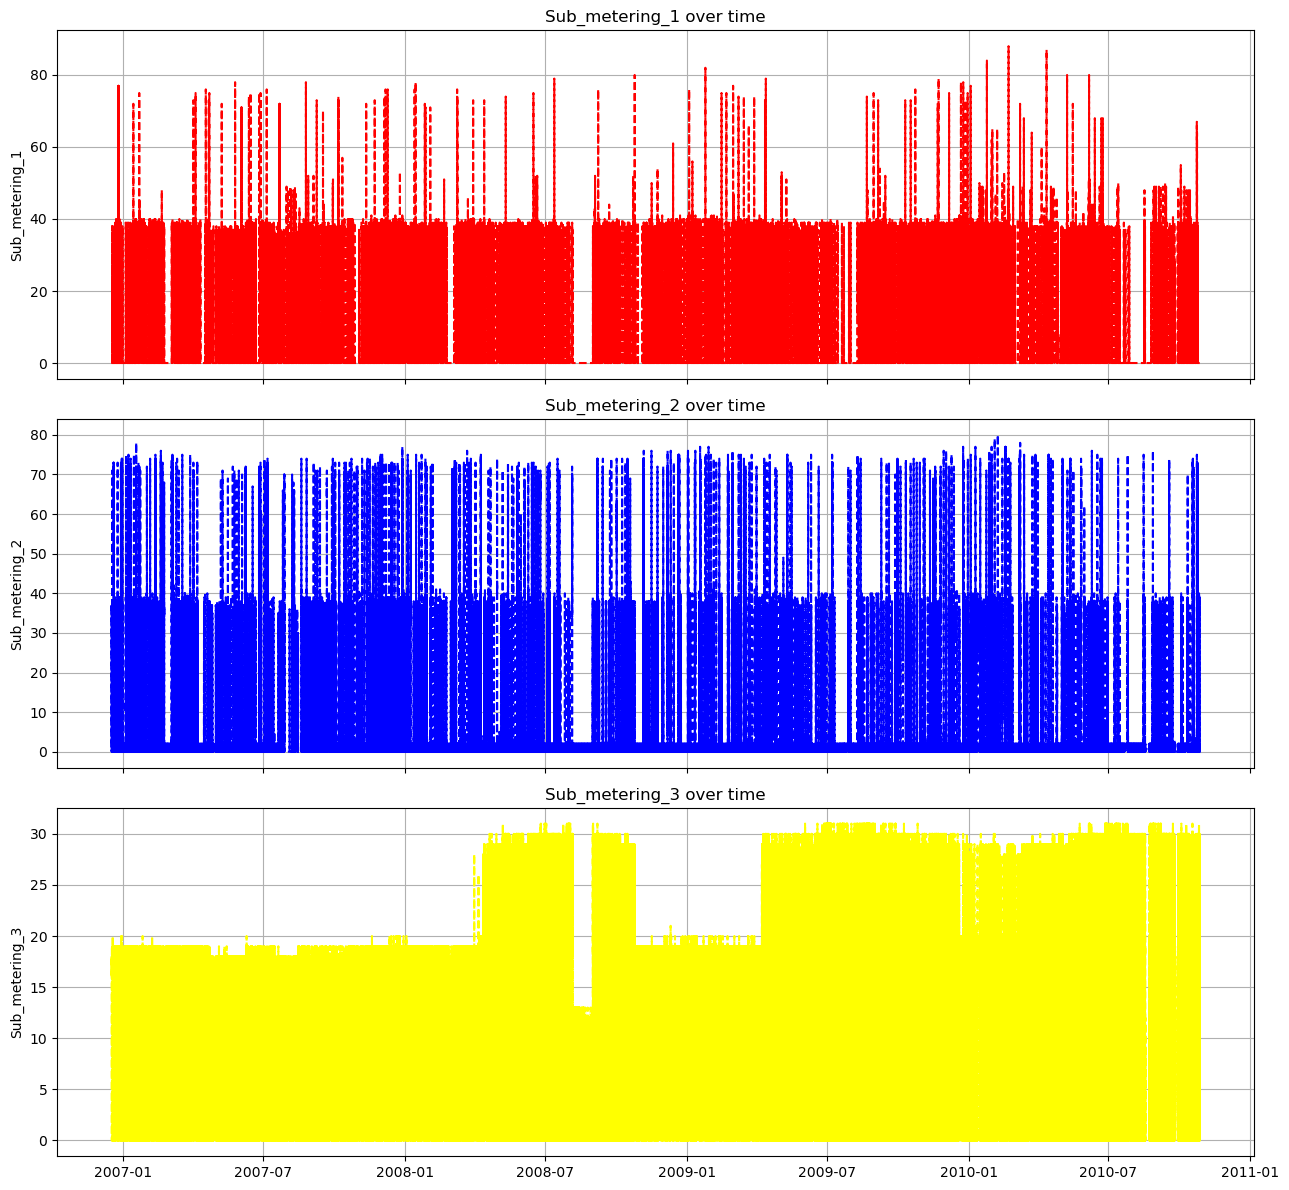

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

# Plot v_red
axes[0].plot(df.index, df['Sub_metering_1'], linestyle='dashed', color='red')
axes[0].set_ylabel('Sub_metering_1')
axes[0].set_title('Sub_metering_1 over time')
axes[0].grid()

# Plot v_blue
axes[1].plot(df.index, df['Sub_metering_2'], linestyle='dashed', color='blue')
axes[1].set_ylabel('Sub_metering_2')
axes[1].set_title('Sub_metering_2 over time')
axes[1].grid()

# Plot v_yellow
axes[2].plot(df.index, df['Sub_metering_3'], linestyle='dashed', color='yellow')
axes[2].set_ylabel('Sub_metering_3')
axes[2].set_title('Sub_metering_3 over time')
axes[2].grid()

# Adjust layout and show the plots
plt.tight_layout()
plt.show()


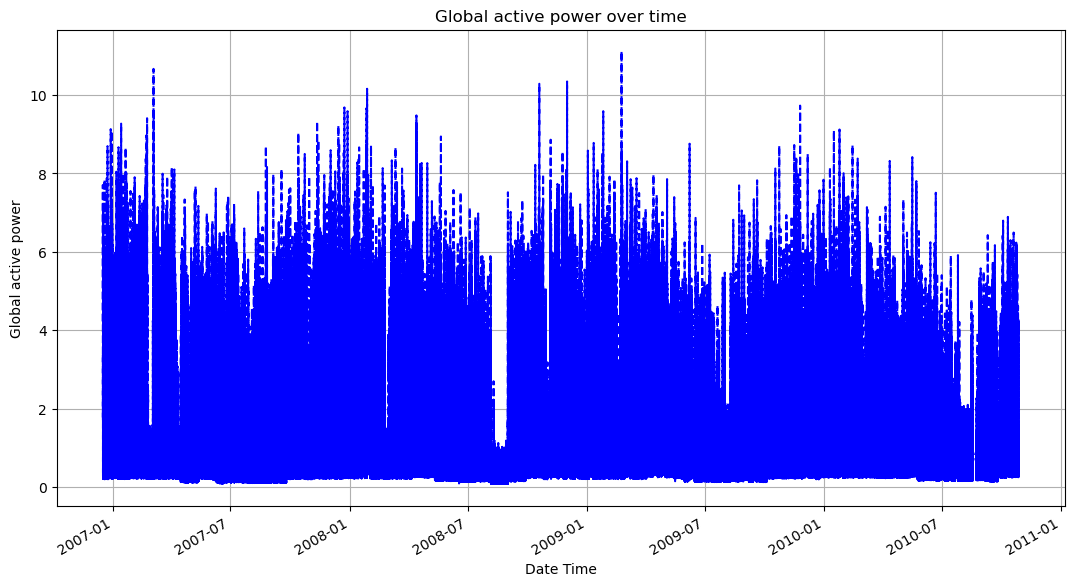

In [27]:
df['Global_active_power'].plot(figsize=(13, 7), linestyle='dashed', color='blue',
                             title='Global active power over time', grid=True)
plt.xlabel('Date Time')
plt.ylabel('Global active power')
plt.show()

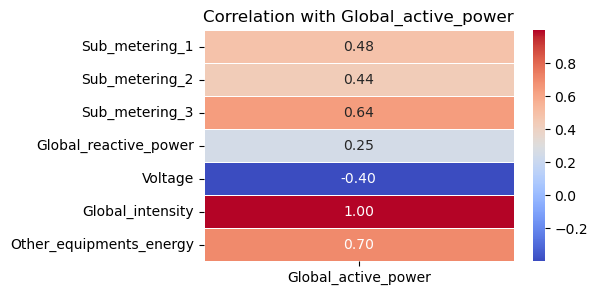

In [28]:
# Compute correlation of 'Global_active_power' with selected features
correlation_matrix = df[['Global_active_power', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3','Global_reactive_power','Voltage','Global_intensity','Other_equipments_energy']].corr()

# Keep only the correlation of 'Global_active_power' with other features
correlation_kwh = correlation_matrix[['Global_active_power']].drop(index='Global_active_power')

# Plot heatmap
plt.figure(figsize=(5, 3))
sns.heatmap(correlation_kwh, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation with Global_active_power")
plt.show()

In [29]:
# Ensure the index is a datetime type
df.index = pd.to_datetime(df.index)

# Create a new 'date' column from the index (YYYY-MM-DD only)
df['date'] = df.index.date

# Now group by 'date' and take the mean for each day
df_daily = df.groupby('date').mean()

# Optional: reset index if you prefer 'date' as a column
df_daily = df_daily.reset_index()

# Display the daily data
df_daily.head()


,date,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Other_equipments_energy,Global_active_power
0,2006-12-16,0.088187,236.243763,13.082828,0.000000,1.378788,12.439394,37.073064,3.053475
1,2006-12-17,0.156949,240.087028,9.999028,1.411806,2.907639,9.264583,25.657407,2.354486
2,2006-12-18,0.112356,241.231694,6.421667,0.738194,1.820139,9.734722,13.214190,1.530435
3,2006-12-19,0.104821,241.999313,4.926389,0.582639,5.279167,4.303472,9.119375,1.157079
4,2006-12-20,0.111804,242.308062,6.467361,0.000000,1.838889,9.765972,14.156111,1.545658


In [30]:
df_daily.shape

(1403, 9)

C:\Users\kdpco\anaconda3\docs\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 7, 64)          │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 7, 32)          │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,665 (194.00 KB)

 Trainable params: 49,665 (194.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step - loss: 0.4787 - val_loss: 0.1145
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 0.1648 - val_loss: 0.0654
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.1070 - val_loss: 0.1016
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.1157 - val_loss: 0.0669
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1135 - val_loss: 0.0640
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1056 - val_loss: 0.0950
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.1098 - val_loss: 0.0808
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1040 - val_loss: 0.0609
Epoch 9/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.1080 - val_loss: 0.0605
Epoch 10/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0958 - val_loss: 0.0597
Epoch 11/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1063 - val_loss: 0.0625
Epoch 12/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.

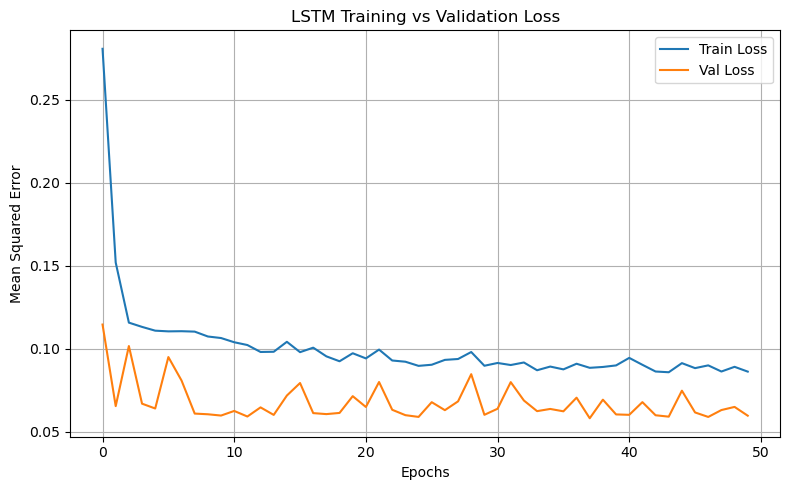

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Select features and target
features_imp = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3',
                'Global_reactive_power', 'Voltage', 'Global_intensity',
                'Other_equipments_energy']
X = df_daily[features_imp].values
y = df_daily['Global_active_power'].values

# Train-test split (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


# Sequence creation
def create_sequences(data, target, time_steps=7):  
    X_seq, y_seq = [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i + time_steps])
        y_seq.append(target[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

X_train_seq, y_train_seq = create_sequences(X_train, y_train)
X_test_seq, y_test_seq = create_sequences(X_test, y_test)

# Build LSTM model
model = Sequential([
    LSTM(64, input_shape=(X_train_seq.shape[1], X_train_seq.shape[2]), return_sequences=True),  # First LSTM layer with return_sequences=True
    LSTM(32, return_sequences=True),# Second LSTM layer, output will be fed into another LSTM layer
    LSTM(32, return_sequences=False), # # Third LSTM layer, output will be fed into Dense layer
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1)  # Output layer for single prediction (Global Active Power)
])

model.compile(loss='mse', optimizer='adam')
model.summary()

# Train the model
history = model.fit(X_train_seq, y_train_seq,
                    epochs=50,
                    batch_size=16,
                    validation_data=(X_test_seq, y_test_seq),
                    verbose=1)

# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.title('LSTM Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show() 

In [86]:
from sklearn.metrics import mean_squared_error
import math
y_pred = model.predict(X_test_seq)

#computing rmse 
rmse = math.sqrt(mean_squared_error(y_test_seq, y_pred))
print(f"RMSE on Test Set: {rmse:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step
RMSE on Test Set: 0.2442


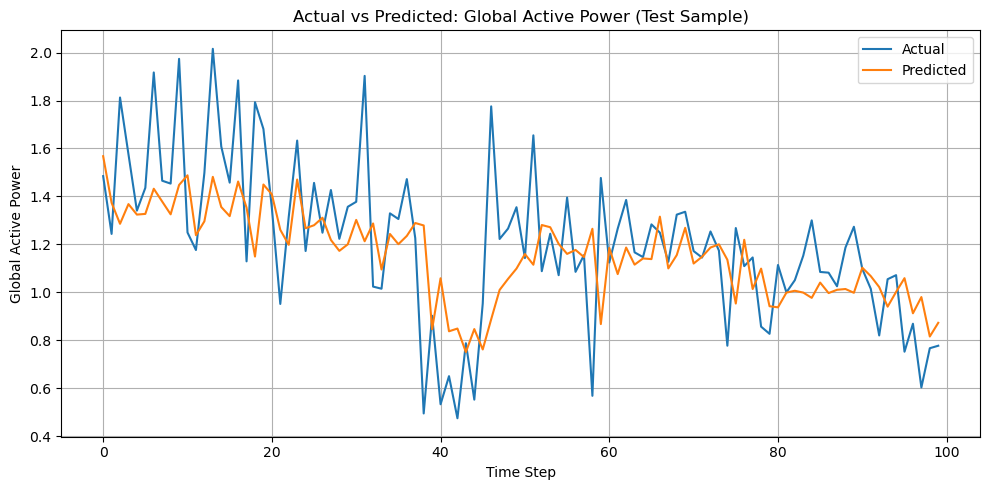

In [89]:
#Actual vs Predicted plot for test dataset
plt.figure(figsize=(10, 5))
plt.plot(y_test_seq[:100], label="Actual")
plt.plot(y_pred[:100], label="Predicted")
plt.title("Actual vs Predicted: Global Active Power (Test Sample)")
plt.xlabel("Time Step")
plt.ylabel("Global Active Power")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [34]:
print(df_daily['date'].min())
print(df_daily['date'].max())

2006-12-16
2010-10-27


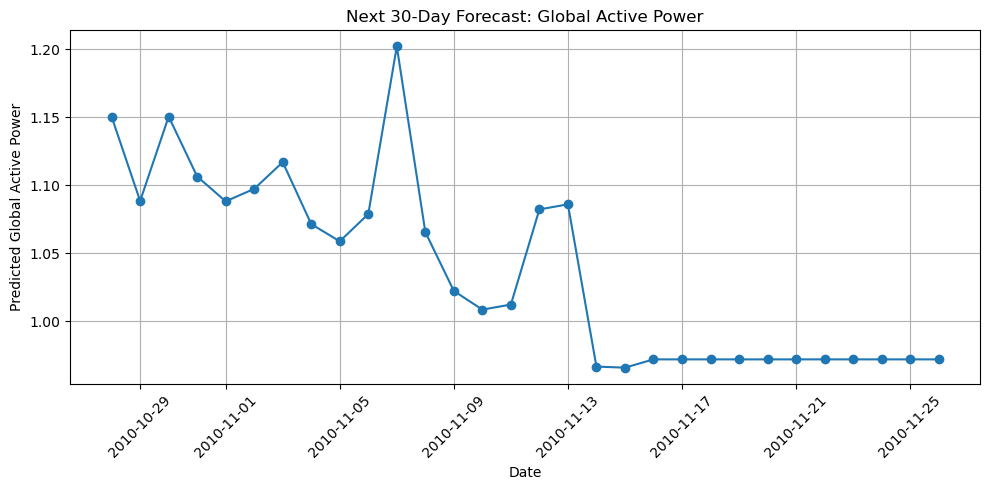

In [91]:
import pandas as pd
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Start from the last available sequence
last_sequence = X_test[-20:]  # Shape: (20, num_features)
future_input = last_sequence.copy()

future_predictions = []

#  Predict next 30 days
for _ in range(30):
    current_input = np.expand_dims(future_input, axis=0)  # Shape: (1, 20, num_features)
    next_pred = model.predict(current_input, verbose=0)[0][0]  # Predict one value
    future_predictions.append(next_pred)

    # Create next input window: drop first row, append predicted row (as dummy inputs)
    next_input = np.append(future_input[1:], [future_input[-1]], axis=0)
    future_input = next_input

# Create dates
last_date = pd.to_datetime("2010-10-27")
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(future_dates, future_predictions, marker='o')
plt.title("Next 30-Day Forecast: Global Active Power")
plt.xlabel("Date")
plt.ylabel("Predicted Global Active Power")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show() 

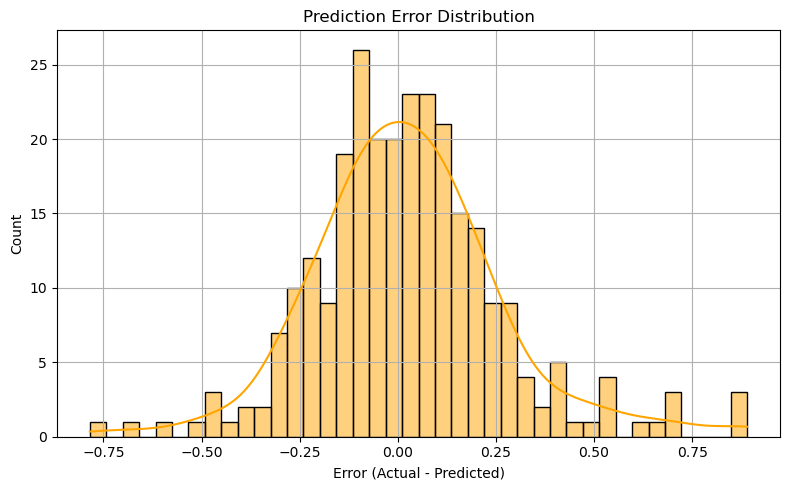

In [93]:
#Error Distribution Histogram
errors = y_test_seq.flatten() - y_pred.flatten()
plt.figure(figsize=(8, 5))
sns.histplot(errors, kde=True, bins=40, color="orange")
plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual - Predicted)")
plt.grid(True)
plt.tight_layout()
plt.show()


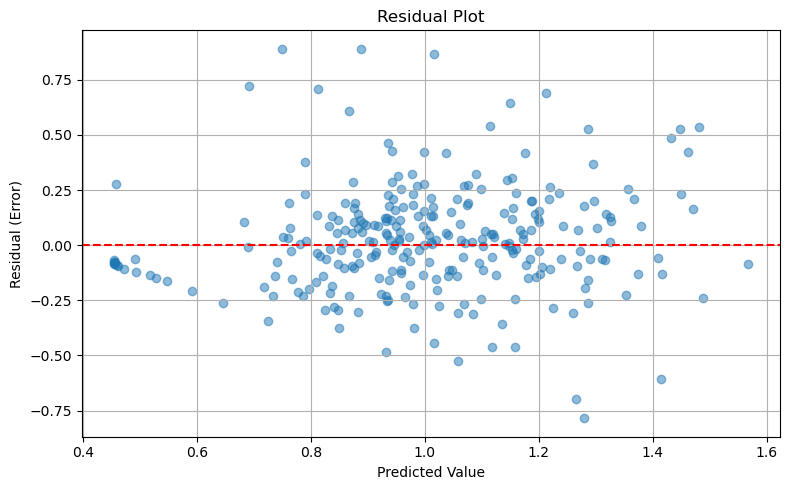

In [95]:
#Residual Plot
plt.figure(figsize=(8, 5))
plt.scatter(y_pred[:500], errors[:500], alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residual Plot")
plt.xlabel("Predicted Value")
plt.ylabel("Residual (Error)")
plt.grid(True)
plt.tight_layout()
plt.show()